# IT Support Incident & Call Analytics — AXA France Account

**Context.** This analysis covers two months (August–September 2024) of IT support activity for the AXA France account, handled by the service desk team I worked on as a Business Data Analyst. It combines the incident ticketing data (ServiceNow export) with the call log data (contact center export) to answer a few operational questions: how volume is trending, where the effort goes, how fast issues get resolved, and what first-call resolution is really worth in practice.

**Data protection note.** All personal identifiers — agent names, caller names, email addresses, site addresses, and call-recording links — were removed or replaced with anonymous codes (`Agent_001`, `Caller_0007`, ...) before this analysis started. See `src/anonymize.py` for the exact method. The raw exports themselves are not part of this repository.

**What's in this notebook**
1. Data loading & quality check
2. Volume trends
3. Where the work comes from (category / subcategory mix)
4. Resolution performance (FCR, resolution time, reopens)
5. Workload distribution
6. Calls vs. incidents
7. Key findings


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10.5
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLOR_PRIMARY = '#2B2154'
COLOR_ACCENT  = '#E8562E'
COLOR_ACCENT2 = '#2E9E77'
COLOR_GREY    = '#9992A6'
PALETTE = [COLOR_PRIMARY, COLOR_ACCENT, COLOR_ACCENT2, '#C9A227', '#6B6478', '#8AA9C9']


## 1. Data loading & quality check

In [2]:
incidents = pd.read_csv('../data/processed/incidents_for_dashboard.csv', parse_dates=['opened_at', 'resolved_at'])
calls = pd.read_csv('../data/processed/calls_for_dashboard.csv', parse_dates=['opened_at'])

print(f"Incidents: {incidents.shape[0]:,} rows x {incidents.shape[1]} columns")
print(f"Calls:     {calls.shape[0]:,} rows x {calls.shape[1]} columns")
incidents.head(3)

Incidents: 7,233 rows x 26 columns
Calls:     3,380 rows x 9 columns


,ticket_id,opened_at,resolved_at,month,contact_type,company,category,subcategory,service,environment,...,reassignment_count,assignment_group,first_call_resolution,knowledge_article_used,resolution_time_hours,opened_by,assigned_to,resolved_by,resolved_by_group,creator_group
0,INC24063427,2024-08-30 18:19:59,2024-08-30 18:35:53,2024-08,Phone,AXA FRANCE ADMIN,Question / aide,How to,My support - Active Directory,Production,...,0,SD_ADMIN_L1_DSIAF,True,AFR WP INQUIRY HOW TO,0.265000,Agent_051,Agent_051,Agent_051,SD_ADMIN_L1_DSIAF,SD_ADMIN_L1_DSIAF
1,INC24063377,2024-08-30 18:03:21,2024-08-30 18:05:26,2024-08,Phone,AXA FRANCE ADMIN,Flash Call,Other,My support - Call Desk,Production,...,0,SD_ADMIN_L1_DSIAF,True,[SILVA] - Procédure - Règles d'utilisation des...,0.034722,Agent_033,Agent_033,Agent_033,SD_ADMIN_L1_DSIAF,SD_ADMIN_L1_DSIAF
2,INC24063215,2024-08-30 17:33:19,2024-08-30 17:53:38,2024-08,Phone,AXA FRANCE AEP,Question / aide,Réinitialisation du mot de passe,My Support - NETIARD,Production,...,0,SD_ADMIN_L1_DSIAF,True,AFR WP MDP WAC/RACF,0.338611,Agent_051,Agent_051,Agent_051,SD_ADMIN_L1_DSIAF,SD_ADMIN_L1_DSIAF


In [3]:
missing = incidents.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing.to_frame('share_missing').style.format('{:.1%}')

,share_missing
major_incident_state,99.8%
resolved_at,7.3%
resolution_time_hours,7.3%
resolved_by,7.3%
resolved_by_group,7.0%
knowledge_article_used,5.2%
closure_code,3.7%
assigned_to,2.7%
creator_group,1.1%
subcategory,0.1%


`resolved_at` is missing for roughly 7% of tickets — these are the ones still open, in a wait state, or pending an external party at export time, so an empty resolution date there is expected rather than a data quality issue. `knowledge_article_used` and `major_incident_state` are mostly empty because most tickets never trigger those workflows. Nothing here needs cleaning beyond what the anonymization step already handled.

In [4]:
duplicate_tickets = incidents['ticket_id'].duplicated().sum()
duplicate_calls = calls['call_id'].duplicated().sum()
print(f"Duplicate ticket IDs: {duplicate_tickets}")
print(f"Duplicate call IDs:   {duplicate_calls}")

Duplicate ticket IDs: 0
Duplicate call IDs:   0


## 2. Volume trends

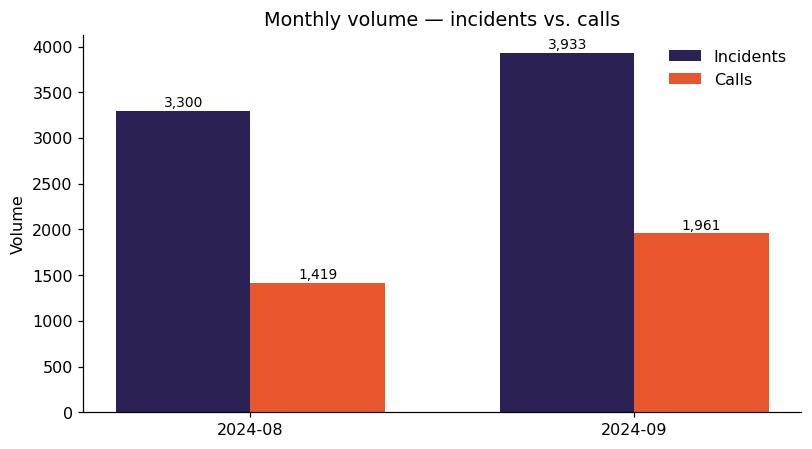

Incident volume grew 19% from August to September
Call volume grew 38% from August to September


In [5]:
monthly_inc = incidents.groupby('month').size()
monthly_call = calls.groupby('month').size()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(monthly_inc))
width = 0.35
ax.bar(x - width/2, monthly_inc.values, width, label='Incidents', color=COLOR_PRIMARY)
ax.bar(x + width/2, monthly_call.reindex(monthly_inc.index).values, width, label='Calls', color=COLOR_ACCENT)
ax.set_xticks(x)
ax.set_xticklabels(monthly_inc.index)
ax.set_ylabel('Volume')
ax.set_title('Monthly volume — incidents vs. calls')
ax.legend(frameon=False)
for i, v in enumerate(monthly_inc.values):
    ax.text(i - width/2, v + 40, f'{v:,}', ha='center', fontsize=9)
for i, v in enumerate(monthly_call.reindex(monthly_inc.index).values):
    ax.text(i + width/2, v + 40, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../visuals/01_monthly_volume.png', bbox_inches='tight')
plt.show()

inc_growth = (monthly_inc.iloc[-1] / monthly_inc.iloc[0] - 1) * 100
call_growth = (monthly_call.iloc[-1] / monthly_call.iloc[0] - 1) * 100
print(f"Incident volume grew {inc_growth:.0f}% from August to September")
print(f"Call volume grew {call_growth:.0f}% from August to September")

Both volumes rise from August to September — a fairly typical back-to-school pattern for a corporate service desk, as password resets, access requests, and onboarding tickets pick up after the summer lull. What stands out is that **calls grew faster than incidents** (+38% vs +19%). That gap is worth watching operationally: it suggests users needed more live back-and-forth per ticket in September, not just more tickets — which usually points to either a spike in more ambiguous issues or a temporary resourcing gap on the desk.

## 3. Where the work comes from

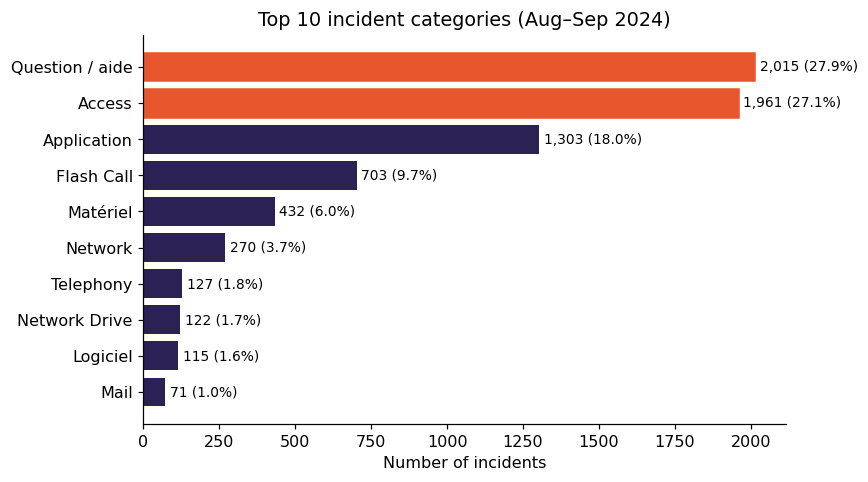

Top 3 categories account for 73.0% of all incidents


In [6]:
cat_counts = incidents['category'].value_counts()
cat_share = (cat_counts / cat_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(cat_counts.index[:10][::-1], cat_counts.values[:10][::-1], color=COLOR_PRIMARY)
bars[-1].set_color(COLOR_ACCENT)
bars[-2].set_color(COLOR_ACCENT)
ax.set_xlabel('Number of incidents')
ax.set_title('Top 10 incident categories (Aug–Sep 2024)')
for i, v in enumerate(cat_counts.values[:10][::-1]):
    ax.text(v + 15, i, f'{v:,} ({cat_share.iloc[:10][::-1].iloc[i]}%)', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../visuals/02_category_breakdown.png', bbox_inches='tight')
plt.show()

top3_share = cat_share.iloc[:3].sum()
print(f"Top 3 categories account for {top3_share:.1f}% of all incidents")

Three categories — **Question / aide**, **Access**, and **Application** — cover more than 70% of everything the desk handles. That concentration is useful: it means a small number of self-service improvements (a better password-reset flow, an FAQ for the most common 'how to' questions) would have an outsized impact on volume, more than trying to optimize the long tail of rare categories.

## 4. Resolution performance

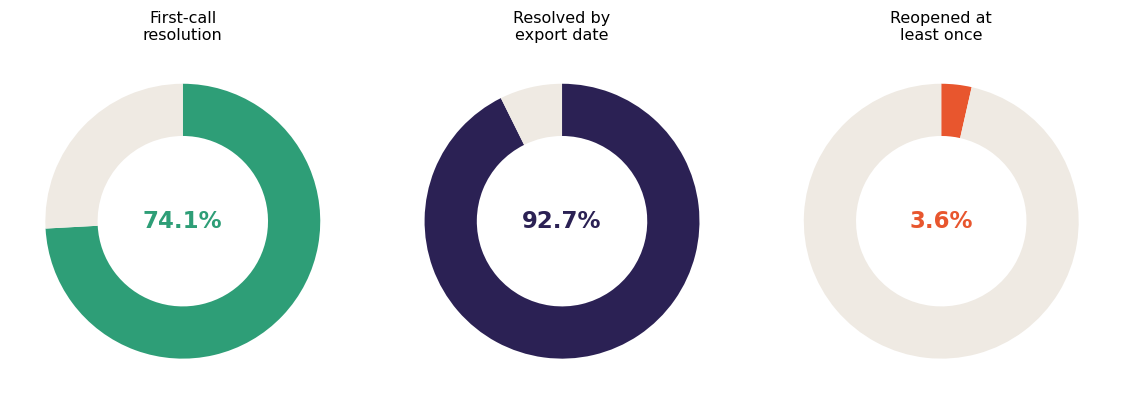

In [7]:
fcr_rate = incidents['first_call_resolution'].mean()
reopen_rate = (incidents['reopen_count'] > 0).mean()
resolved_share = incidents['resolved_at'].notna().mean()

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
metrics = [('First-call\nresolution', fcr_rate), ('Resolved by\nexport date', resolved_share), ('Reopened at\nleast once', reopen_rate)]
colors = [COLOR_ACCENT2, COLOR_PRIMARY, COLOR_ACCENT]
for ax, (label, val), c in zip(axes, metrics, colors):
    ax.pie([val, 1-val], colors=[c, '#EFEAE3'], startangle=90, counterclock=False,
           wedgeprops=dict(width=0.38))
    ax.text(0, 0, f'{val*100:.1f}%', ha='center', va='center', fontsize=15, fontweight='bold', color=c)
    ax.set_title(label, fontsize=10.5)
plt.tight_layout()
plt.savefig('../visuals/03_resolution_kpis.png', bbox_inches='tight')
plt.show()

**74.1%** of incidents are resolved on the first contact, **3.6%** get reopened at least once, and by export date **93%** had a resolution timestamp — a healthy baseline for a level-1 desk. The number worth digging into is the reopen rate: it's low in absolute terms, but at this ticket volume it's still roughly 250 tickets a month where the first fix didn't hold.

/tmp/ipykernel_596/3962157721.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_fcr_capped, data_nofcr_capped], labels=['First-call resolution', 'Not resolved on first call'],


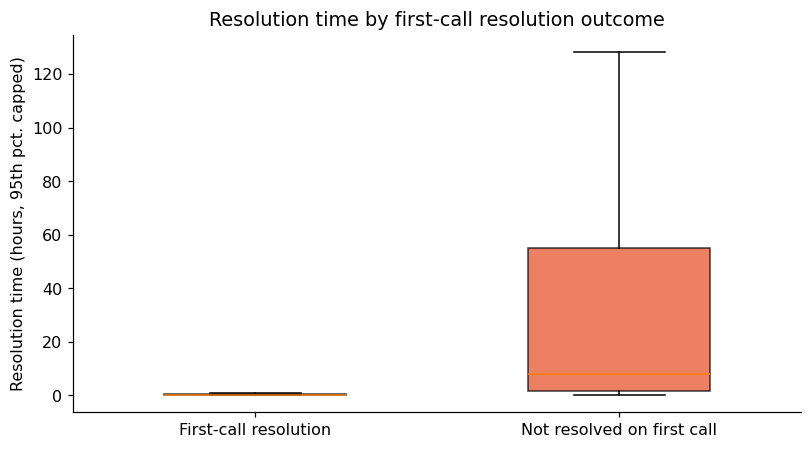

Median resolution time — FCR:     12 minutes
Median resolution time — non-FCR: 7.7 hours
Mann-Whitney U test p-value: 0


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
data_fcr = incidents.loc[incidents.first_call_resolution == True, 'resolution_time_hours'].dropna()
data_nofcr = incidents.loc[incidents.first_call_resolution == False, 'resolution_time_hours'].dropna()
data_fcr_capped = data_fcr.clip(upper=data_fcr.quantile(0.95))
data_nofcr_capped = data_nofcr.clip(upper=data_nofcr.quantile(0.95))

bp = ax.boxplot([data_fcr_capped, data_nofcr_capped], labels=['First-call resolution', 'Not resolved on first call'],
                 patch_artist=True, widths=0.5, showfliers=False)
for patch, c in zip(bp['boxes'], [COLOR_ACCENT2, COLOR_ACCENT]):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
ax.set_ylabel('Resolution time (hours, 95th pct. capped)')
ax.set_title('Resolution time by first-call resolution outcome')
plt.tight_layout()
plt.savefig('../visuals/04_resolution_time_fcr.png', bbox_inches='tight')
plt.show()

u_stat, p_value = stats.mannwhitneyu(data_fcr, data_nofcr, alternative='two-sided')
print(f"Median resolution time — FCR:     {data_fcr.median()*60:.0f} minutes")
print(f"Median resolution time — non-FCR: {data_nofcr.median():.1f} hours")
print(f"Mann-Whitney U test p-value: {p_value:.4g}")

The difference is large and statistically significant (Mann-Whitney U, p < 0.001): tickets resolved on the first contact close in a median of **~12 minutes**, against **~7.7 hours** for everything else. That's not a subtle effect — it's roughly a 38x gap. It reframes the FCR metric from 'nice to have' to the single biggest lever on the team's actual workload, since every ticket that escapes first-contact resolution consumes disproportionately more queue time, not just a little more.

## 5. Workload distribution

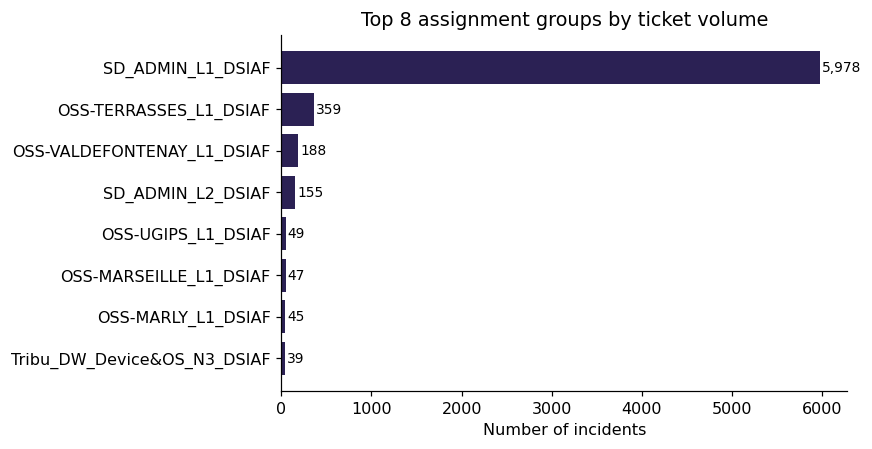

The largest group alone handles 82.6% of all incidents


In [9]:
group_counts = incidents['assignment_group'].value_counts().head(8)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(group_counts.index[::-1], group_counts.values[::-1], color=COLOR_PRIMARY)
ax.set_xlabel('Number of incidents')
ax.set_title('Top 8 assignment groups by ticket volume')
for i, v in enumerate(group_counts.values[::-1]):
    ax.text(v + 20, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../visuals/05_assignment_groups.png', bbox_inches='tight')
plt.show()

top_group_share = group_counts.iloc[0] / len(incidents) * 100
print(f"The largest group alone handles {top_group_share:.1f}% of all incidents")

One group — the main L1 admin desk — absorbs the large majority of tickets, with the regional OSS site teams handling smaller, fairly even slices. That's the expected shape for a hub-and-spoke support model, but it also means that any slowdown in the main L1 queue has an outsized effect on the team's overall numbers; the smaller groups have much less influence on the aggregate KPIs.

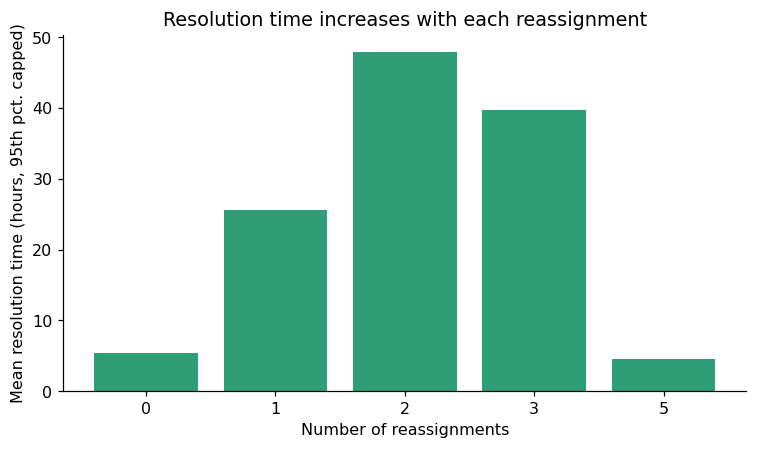

Spearman correlation (reassignment count vs. resolution time): 0.26


In [10]:
reassign_corr = incidents[['reassignment_count', 'resolution_time_hours']].corr(method='spearman').iloc[0,1]

fig, ax = plt.subplots(figsize=(7, 4.2))
sample = incidents.dropna(subset=['resolution_time_hours']).copy()
sample['resolution_time_hours_capped'] = sample['resolution_time_hours'].clip(upper=sample['resolution_time_hours'].quantile(0.95))
means = sample.groupby('reassignment_count')['resolution_time_hours_capped'].mean()
means = means[means.index <= 5]
ax.bar(means.index.astype(str), means.values, color=COLOR_ACCENT2)
ax.set_xlabel('Number of reassignments')
ax.set_ylabel('Mean resolution time (hours, 95th pct. capped)')
ax.set_title('Resolution time increases with each reassignment')
plt.tight_layout()
plt.savefig('../visuals/06_reassignment_impact.png', bbox_inches='tight')
plt.show()

print(f"Spearman correlation (reassignment count vs. resolution time): {reassign_corr:.2f}")

Reassignment count and resolution time move together (Spearman ρ ≈ 0.26) — every extra hop between groups adds real delay. It's a moderate correlation rather than a strong one, which fits the story from section 4: *whether the ticket gets fixed on the first contact* still explains far more of the variation than *how many times it gets passed around* afterward.

## 6. Calls vs. incidents

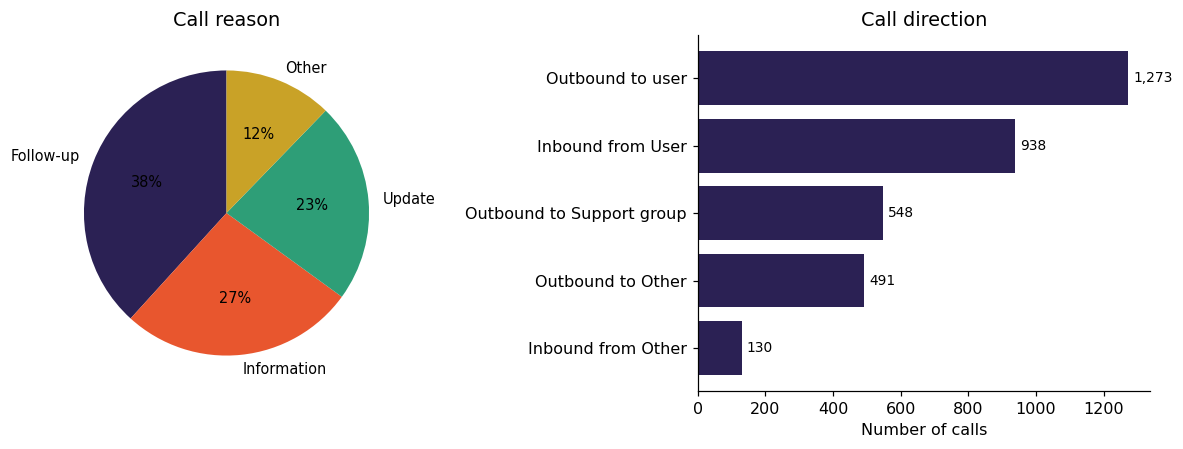

100% of logged calls are tied to a specific incident number
68% of calls are outbound (agent calling the user), not inbound


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

reason_counts = calls['call_reason'].value_counts()
axes[0].pie(reason_counts.values, labels=reason_counts.index, autopct='%1.0f%%',
            colors=PALETTE, startangle=90, textprops={'fontsize': 9.5})
axes[0].set_title('Call reason')

dir_counts = calls['call_direction'].value_counts()
axes[1].barh(dir_counts.index[::-1], dir_counts.values[::-1], color=COLOR_PRIMARY)
axes[1].set_xlabel('Number of calls')
axes[1].set_title('Call direction')
for i, v in enumerate(dir_counts.values[::-1]):
    axes[1].text(v + 15, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/07_calls_breakdown.png', bbox_inches='tight')
plt.show()

pct_linked = calls['linked_incident'].notna().mean() * 100
outbound_share = calls['call_direction'].str.contains('Outbound').mean() * 100
print(f"{pct_linked:.0f}% of logged calls are tied to a specific incident number")
print(f"{outbound_share:.0f}% of calls are outbound (agent calling the user), not inbound")

Every logged call ties back to an incident number, and the majority are **outbound** — the agent calling the user for a follow-up or a status update, rather than the user calling in. Combined with `call_reason` being dominated by *Follow-up* and *Update*, this says something concrete about where phone time actually goes on this desk: not first-contact troubleshooting, but chasing users for information or closing the loop after work already done elsewhere. That's a process signal, not just a volume one — it points at possible gains from proactive status notifications that would reduce the need for outbound follow-up calls altogether.

## 7. Key findings

- **Volume is growing month over month** (+19% incidents, +38% calls from August to September), with calls growing faster than incidents — a sign that issues needed more manual follow-up in September, not just that there were more of them.
- **Three categories drive over 70% of ticket volume** (Question/aide, Access, Application) — the clearest lever for reducing inbound load is self-service on these three, not broad process changes.
- **First-call resolution is the single biggest driver of resolution speed**: FCR tickets close in a median of ~12 minutes versus ~7.7 hours otherwise (p < 0.001) — investing in agent enablement for first-contact fixes has an outsized payoff.
- **Reassignments correlate with slower resolution** (Spearman ρ ≈ 0.26), but the effect is secondary to first-call resolution.
- **Most outbound calls are follow-ups, not troubleshooting** — proactive status updates could reduce call volume without touching resolution quality.
- Reopen rate is low (3.6%) but represents roughly 250 tickets a month that didn't stay fixed — worth a closer look at *which* categories reopen most, as a natural next analysis.

The processed tables behind every chart in this notebook (`data/processed/incidents_for_dashboard.csv`, `data/processed/calls_for_dashboard.csv`) also feed the Power BI dashboard in `/powerbi`, which makes these same KPIs explorable by month, category, and assignment group.